# Title


## Setup

### Import Libraries

In [20]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
from torch.utils.data import random_split

import pandas as pd
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

### Set Seed

In [57]:
SEED = 42
torch.manual_seed(SEED)

### Prepare Data

#### Create Custom Data Class for Wine Dataset

In [4]:
class WineDataset(Dataset):
    def __init__(self):
        # load data
        df = pd.read_csv('data/raw/wine.csv')

        self.features = torch.tensor(df.drop(columns = 'Wine').values, dtype=torch.float32)
        self.labels = torch.tensor(df['Wine'].values, dtype = torch.long) - 1 # subtract 1 to start at 0

    def __len__(self):
        '''Get the number of samples in the dataset'''
        return len(self.labels)
    
    def __getitem__(self, index):
        return self.features[index], self.labels[index]

#### Split Data into Train, Validation, and Test Subsets

In [5]:
train_fraction = 0.7
val_fraction = 0.15
test_fraction = 1-train_fraction-val_fraction

train_data, val_data, test_data = random_split(WineDataset(), lengths=[train_fraction, val_fraction, test_fraction])

#### Create Dataloaders for Each Subset

In [6]:
train_dataloader = DataLoader(train_data, shuffle=True, batch_size=8, drop_last=True)
val_dataloader = DataLoader(val_data, shuffle=True, batch_size=len(val_data))
test_dataloader = DataLoader(test_data, shuffle=True, batch_size=len(test_data))

### Create Model

In [7]:
class SimpleNeuralNet(nn.Module):
    def __init__(self,):
        super().__init__()

        self.layers = nn.Sequential(
            nn.Linear(13, 16),
            nn.ReLU(),
            nn.Linear(16,13)
        )

    def forward(self, x):
        output = self.layers(x)
        return output

## Section 1: Normalize Data


| Code | Description |
|---|---|
| `StandardScaler().fit_transform(data)` | Scales the data by standardizing it. It subtracts the mean and divides by the standard deviation. |
| `RobustScaler().fit_transform(data)` | Scales the data using median and interquartile range. Reduces effect of outliers. |
| `MinMaxScaler().fit_transform(data)` | Scales the data using the range between the minimum and maximum value. |

#### **Exercises**


In [16]:
wine = WineDataset()

features_unscaled = wine.features.numpy()

features_unscaled

array([[1.423e+01, 1.710e+00, 2.430e+00, ..., 1.040e+00, 3.920e+00,
        1.065e+03],
       [1.320e+01, 1.780e+00, 2.140e+00, ..., 1.050e+00, 3.400e+00,
        1.050e+03],
       [1.316e+01, 2.360e+00, 2.670e+00, ..., 1.030e+00, 3.170e+00,
        1.185e+03],
       ...,
       [1.327e+01, 4.280e+00, 2.260e+00, ..., 5.900e-01, 1.560e+00,
        8.350e+02],
       [1.317e+01, 2.590e+00, 2.370e+00, ..., 6.000e-01, 1.620e+00,
        8.400e+02],
       [1.413e+01, 4.100e+00, 2.740e+00, ..., 6.100e-01, 1.600e+00,
        5.600e+02]], shape=(178, 13), dtype=float32)

**Example**: Scale the features (extracted and assigned to `features_unscaled` above) in the wine dataset by standardizing it. Update the features attribute of the wine dataset with the scaled data.

Compare the values of the scaled features to the unscaled features displayed above. Do they look the way you would expect for standardized data?

In [17]:
wine.features = torch.tensor(StandardScaler().fit_transform(features_unscaled), dtype=torch.float32)
wine.features

tensor([[ 1.5186, -0.5622,  0.2321,  ...,  0.3622,  1.8479,  1.0130],
        [ 0.2463, -0.4994, -0.8280,  ...,  0.4061,  1.1134,  0.9652],
        [ 0.1969,  0.0212,  1.1093,  ...,  0.3183,  0.7886,  1.3951],
        ...,
        [ 0.3328,  1.7447, -0.3894,  ..., -1.6121, -1.4854,  0.2806],
        [ 0.2092,  0.2277,  0.0127,  ..., -1.5683, -1.4007,  0.2965],
        [ 1.3951,  1.5832,  1.3652,  ..., -1.5244, -1.4289, -0.5952]])

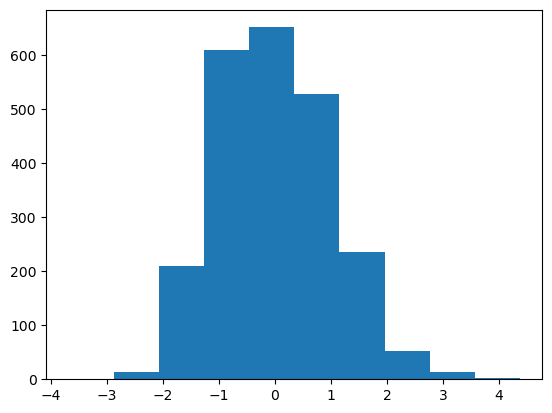

In [19]:
plt.hist(wine.features.flatten());

**Exercise**: Scale the features (`features_unscaled`) in the wine dataset with the `RobustScaler()` it. Update the features attribute of the wine dataset with the scaled data.

In [21]:
wine.features = torch.tensor(RobustScaler().fit_transform(features_unscaled), dtype=torch.float32)
wine.features

tensor([[ 0.8973, -0.1047,  0.2014,  ...,  0.2222,  0.9249,  0.8080],
        [ 0.1141, -0.0574, -0.6331,  ...,  0.2519,  0.5030,  0.7771],
        [ 0.0836,  0.3345,  0.8921,  ...,  0.1926,  0.3164,  1.0557],
        ...,
        [ 0.1673,  1.6318, -0.2878,  ..., -1.1111, -0.9899,  0.3333],
        [ 0.0913,  0.4899,  0.0288,  ..., -1.0815, -0.9412,  0.3437],
        [ 0.8213,  1.5101,  1.0935,  ..., -1.0519, -0.9574, -0.2343]])

**Exercise**: Scale the features (`features_unscaled`) in the wine dataset with the `MinMaxScaler()` it. Update the features attribute of the wine dataset with the scaled data.

Compare the values of the scaled features to the unscaled features displayed above. Do they look the way you would expect for data normalized by the range between the min and max value?

In [23]:
wine.features = torch.tensor(MinMaxScaler().fit_transform(features_unscaled), dtype=torch.float32)
wine.features

tensor([[0.8421, 0.1917, 0.5722,  ..., 0.4553, 0.9707, 0.5613],
        [0.5711, 0.2055, 0.4171,  ..., 0.4634, 0.7802, 0.5506],
        [0.5605, 0.3202, 0.7005,  ..., 0.4472, 0.6960, 0.6469],
        ...,
        [0.5895, 0.6996, 0.4813,  ..., 0.0894, 0.1062, 0.3973],
        [0.5632, 0.3656, 0.5401,  ..., 0.0976, 0.1282, 0.4009],
        [0.8158, 0.6640, 0.7380,  ..., 0.1057, 0.1209, 0.2011]])

## Section 2: Train with Dataloaders

The code below goes through all batches in the `dataloader` and passes the features from each batch as input to the model.

```python
for (batch_features, batch_labels) in range(dataloader):
    output = model.forward(batch_features)
```

The code above does the same thing, but does it 100 times - once for each epoch.

```python
n_epochs = 100
for epoch in range(n_epochs):
    for (batch_features, batch_labels) in range(dataloader):
        output = model.forward(batch_features)
```


| Code | Description |
|---|---|
| `for x_i in x:` <br> &nbsp;&nbsp;&nbsp;&nbsp; `print(x_i)` | Print every element `x_i` in the collection `x`|
| `for x_i in x:` <br> &nbsp;&nbsp;&nbsp;&nbsp; `for y_i in y`: <br> &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; `print(x_i, y_i)` | Print every element `x_i` and `y_i` in the collections `x` and `y`|
| `new_list = []` or `new_list = list()`| Initialize an empty list named `new_list` |
| `new_list.append(element)`| Append an element to the list `new_list` |
| `loss_function(output_model, labels)` | Calculates the loss between the output of the network `output_model` and the true labels from the data `labels`. |
| `loss_function(output_model, labels).item()` | Extracts the loss value (the number alone as a ``float`` and not as a ``tensor`` type). |
| `optim.Adam(net.parameters())` | Creates an Adaptive Moment estimation (Adam) optimizer. |
| `optimizer = optim.SGD(net.parameters())` | Creates an Adaptive Moment estimation (Adam) optimizer and assigns it to a variable called `optimizer`. |
| `optimizer.zero_grad()` | Resets the gradients before the next iteration in the optimization. |
| `loss.backward()`| Performs backward propagation and calculates the gradients through the graph leaves (network). |
| `optimizer.step()` | Update the parameters of the network. |


#### **Exercises**

Run the cell below to instantiate the model, the optimizer and the loss function.

In [78]:
model = SimpleNeuralNet()

optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)

loss_function = nn.CrossEntropyLoss()

**Example**: Complete the code below and put it inside a for loop that goes through the batches in the dataloader for the training data. 

In [ ]:
# pass the input to the network
train_output = ___
    
# calculate the loss
loss = loss_function(train_output, ___)

In [ ]:
for batch_idx, (batch_train_features, batch_train_labels) in enumerate(train_dataloader):
    # pass the input to the network
    train_output = model.forward(batch_train_features)

    # calculate the loss
    loss = loss_function(train_output, batch_train_labels)

**Exercise**: Complete the code below and put it inside a for loop that goes through the batches in the dataloader for the training data. The model parameters will then be updated for each batch in the training data.

In [ ]:
# reset the gradients of the optimizer
___

# pass the input to the network
train_output = model.forward(batch_train_features)

# calculate the loss
loss = loss_function(train_output, batch_train_labels)

# perform backward propagation to calculate the gradients
loss.backward()

# update the parameters of the model
___

In [ ]:
for batch_idx, (batch_train_features, batch_train_labels) in enumerate(train_dataloader):
    # reset the gradients of the optimizer
    optimizer.zero_grad()

    # pass the input to the network
    train_output = model.forward(batch_train_features)

    # calculate the loss
    loss = loss_function(train_output, batch_train_labels)

    # perform backward propagation to calculate the gradients
    loss.backward()

    # update the parameters of the model
    optimizer.step()

**Exercise**: Initialize an empty list named `batch_losses` before the loop in the cell below and append the calculated loss to this list in each iteration.

**Hint**: Use `loss.item()` to get the extract the loss as a float.

In [71]:
# initialize batch losses list
___
for batch_idx, (batch_train_features, batch_train_labels) in enumerate(train_dataloader):
    # reset the gradients of the optimizer
    optimizer.zero_grad()

    # pass the input to the network
    train_output = model.forward(batch_train_features)

    # calculate the loss
    loss = loss_function(train_output, batch_train_labels)

    # perform backward propagation to calculate the gradients
    loss.backward()

    # update the parameters of the model
    optimizer.step()

    # append loss computed in this iteration to batch losses
    ___

In [ ]:
# initialize batch losses list
batch_losses = []
for batch_idx, (batch_train_features, batch_train_labels) in enumerate(train_dataloader):
    # reset the gradients of the optimizer
    optimizer.zero_grad()

    # pass the input to the network
    train_output = model.forward(batch_train_features)

    # calculate the loss
    loss = loss_function(train_output, batch_train_labels)

    # perform backward propagation to calculate the gradients
    loss.backward()

    # update the parameters of the model
    optimizer.step()

    # append loss computed in this iteration to batch losses
    batch_losses.append(loss.item())

**Example**: When training a network, we also want to loop through the epochs, not just the batches in the dataloader. Add an outer loop of 100 epochs to the code below. The result will be a double loop, one outer loop that goes through all epochs from 0 to 99 and one inner loop that goes through the batches in the dataloader.

In [ ]:
n_epochs = 100
# outer loop through epochs
___
# inner loop through batches in dataloader
for batch_idx, (batch_train_features, batch_train_labels) in enumerate(train_dataloader):
    # pass the input to the network
    train_output = model.forward(batch_train_features)

    # calculate the loss
    loss = loss_function(train_output, batch_train_labels)

In [ ]:
n_epochs = 100
# outer loop through epochs
for epoch in range(n_epochs):
    # inner loop through batches in dataloader
    for batch_idx, (batch_train_features, batch_train_labels) in enumerate(train_dataloader):
        # pass the input to the network
        train_output = model.forward(batch_train_features)

        # calculate the loss
        loss = loss_function(train_output, batch_train_labels)

**Exercise**: Add outer loop through the epochs to the code below. In this code (as opposed to the code in the example above), the parameters are updated as well, meaning that the model is trained as we loop through the epochs and data batches. Set `n_epochs` to 50.

In [ ]:

# outer loop through epochs
___

# inner loop through batches in dataloader
for batch_idx, (batch_train_features, batch_train_labels) in enumerate(train_dataloader):
    # reset the gradients of the optimizer
    optimizer.zero_grad()

    # pass the input to the network
    train_output = model.forward(batch_train_features)

    # calculate the loss
    loss = loss_function(train_output, batch_train_labels)

    # perform backward propagation to calculate the gradients
    loss.backward()

    # update the parameters of the model
    optimizer.step()

#### **Extra Challenge**

**Exercise**: Add outer loop through the epochs to the code below. Furthermore, initilize a list to store the loss in each epoch. The loss in each epoch should be the average of the list of losses through the batches.

**Hint**: The mean across bath losses can be calculated with `np.mean()`

In [ ]:
# initialize epoch losses list
___

# outer loop through epochs
___
    # initialize batch losses list
    batch_losses = []
    for batch_idx, (batch_train_features, batch_train_labels) in enumerate(train_dataloader):
        # reset the gradients of the optimizer
        optimizer.zero_grad()

        # pass the input to the network
        train_output = model.forward(batch_train_features)

        # calculate the loss
        loss = loss_function(train_output, batch_train_labels)

        # perform backward propagation to calculate the gradients
        loss.backward()

        # update the parameters of the model
        optimizer.step()

        # append loss computed in this iteration to batch losses
        batch_losses.append(loss.item())

    # append the average of batch losses to the list of losses in each epoch
    ___

In [73]:
# initialize epoch losses list
epoch_losses = []

n_epochs = 100
# outer loop through epochs
for epoch in range(n_epochs):
    # initialize batch losses list
    batch_losses = []
    for batch_idx, (batch_train_features, batch_train_labels) in enumerate(train_dataloader):
        # reset the gradients of the optimizer
        optimizer.zero_grad()

        # pass the input to the network
        train_output = model.forward(batch_train_features)

        # calculate the loss
        loss = loss_function(train_output, batch_train_labels)

        # perform backward propagation to calculate the gradients
        loss.backward()

        # update the parameters of the model
        optimizer.step()

        # append loss computed in this iteration to batch losses
        batch_losses.append(loss.item())

    # append the average of batch losses to the list of losses in each epoch
    epoch_losses.append(np.mean(batch_losses))

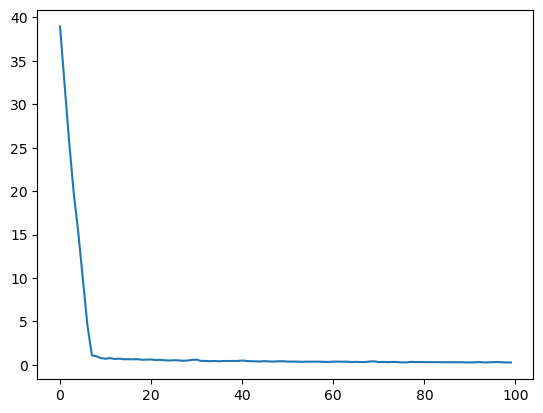

In [ ]:
plt.plot(epoch_losses)

#### DEMO: Calculate Accuracy During and After Training

In [82]:
n_epochs = 200

optimizer = torch.optim.Adam(model.parameters())

loss_function = nn.CrossEntropyLoss()

accuracy_epochs = []
for epoch in range(n_epochs):

    accuracy_batches = []
    for train_features, train_labels in train_dataloader:
        optimizer.zero_grad()

        output = model.forward(train_features)

        accuracy = torch.sum(torch.argmax(output, dim=1) == train_labels)/len(train_labels)
        accuracy_batches.append(accuracy)

        loss = loss_function(output, train_labels)

        loss.backward()

        optimizer.step()

    if (epoch % 20) == 0:
        print(f'Accuracy: {accuracy}, loss: {loss.item()}')
        print(f'Predicted labels: {torch.argmax(output, dim=1)}, true labels: {train_labels}')

    accuracy_epochs.append(np.mean(accuracy_batches))

Accuracy: 0.75, loss: 0.8729611039161682
Predicted labels: tensor([0, 0, 1, 0, 0, 0, 2, 1]), true labels: tensor([1, 0, 1, 0, 0, 1, 2, 1])


Accuracy: 0.875, loss: 0.2503011226654053
Predicted labels: tensor([1, 2, 0, 1, 1, 0, 1, 0]), true labels: tensor([1, 2, 0, 0, 1, 0, 1, 0])
Accuracy: 1.0, loss: 0.05388632416725159
Predicted labels: tensor([0, 0, 1, 0, 0, 2, 0, 0]), true labels: tensor([0, 0, 1, 0, 0, 2, 0, 0])
Accuracy: 0.75, loss: 0.27502498030662537
Predicted labels: tensor([2, 2, 0, 1, 2, 2, 0, 2]), true labels: tensor([1, 2, 0, 0, 2, 2, 0, 2])
Accuracy: 0.875, loss: 0.2170983850955963
Predicted labels: tensor([1, 0, 1, 2, 0, 2, 0, 0]), true labels: tensor([2, 0, 1, 2, 0, 2, 0, 0])
Accuracy: 1.0, loss: 0.18661849200725555
Predicted labels: tensor([1, 1, 0, 0, 0, 0, 1, 0]), true labels: tensor([1, 1, 0, 0, 0, 0, 1, 0])
Accuracy: 1.0, loss: 0.07811728864908218
Predicted labels: tensor([1, 0, 0, 0, 1, 0, 0, 2]), true labels: tensor([1, 0, 0, 0, 1, 0, 0, 2])
Accuracy: 1.0, loss: 0.0804295614361763
Predicted labels: tensor([1, 2, 1, 2, 0, 1, 1, 0]), true labels: tensor([1, 2, 1, 2, 0, 1, 1, 0])
Accuracy: 1.0, loss: 0.11

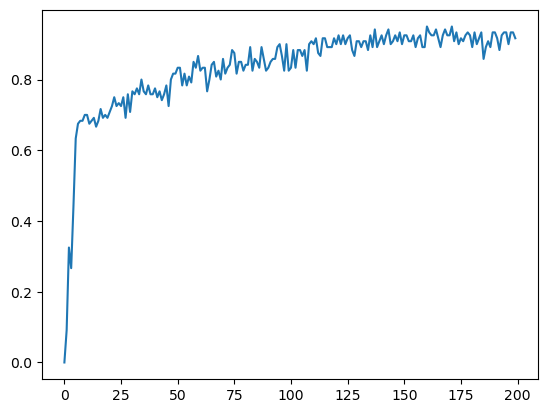

In [80]:
plt.plot(np.array(accuracy_epochs))

In [81]:
test_features, test_labels = next(iter(test_dataloader))

output = model(test_features)

pred_labels = torch.argmax(output, dim=1)

test_accuracy = (pred_labels == test_labels).sum()/len(test_labels)
test_accuracy

tensor(0.8846)

## Section 3: Augment Data

Purpose: Prevent overfitting/Improve Generalization

| Code | Description |
|---|---|
| `data_aug = data_nonaug + torch.randn_like(data_nonaug)*scale_noise_num` | Adds gaussian noise to the data. |
| `mask = torch.bernoulli(torch.ones_like(data_nonaug)*some_fraction)` <br> `data_aug = data_nonaug[mask]` | Randomly drops some fraction of the data. |


#### **Exercises**


Run the cell below to standardize the features in the wine dataset.

In [50]:
wine.features = torch.tensor(StandardScaler().fit_transform(features_unscaled), dtype=torch.float32)
features_nonaug = wine.features

**Example**: Add gaussian noise to the features. Scale the noise by ``0.05`` (this makes the noise have a standard deviation of `0.05`).

In [55]:
scale_noise_num = 0.05
features_aug = features_nonaug + torch.randn_like(features_nonaug)*scale_noise_num
features_aug

tensor([[ 1.5270, -0.5757,  0.1855,  ...,  0.3807,  1.7771,  1.0176],
        [ 0.3194, -0.5803, -0.7608,  ...,  0.4453,  1.1407,  1.0085],
        [ 0.1465, -0.0170,  1.0975,  ...,  0.2253,  0.7499,  1.3823],
        ...,
        [ 0.3790,  1.7315, -0.3516,  ..., -1.5757, -1.4178,  0.3039],
        [ 0.2433,  0.2029, -0.0117,  ..., -1.6011, -1.3347,  0.2123],
        [ 1.4286,  1.5688,  1.4352,  ..., -1.5230, -1.4506, -0.6622]])

**Exercise**: Add gaussian noise to the features. Scale the noise by ``0.7``. Display the features after the noise has been added.

In [56]:
scale_noise_num = 0.7
features_aug = features_nonaug + torch.randn_like(features_nonaug)*scale_noise_num
features_aug

tensor([[ 1.6564, -0.6806,  0.3877,  ...,  0.5455,  2.1094, -0.1637],
        [-0.9906,  0.1093, -0.2197,  ..., -0.6490,  1.1086,  1.9808],
        [-0.2379,  1.4260,  1.8432,  ...,  0.5368, -0.4783,  1.5972],
        ...,
        [ 1.4691,  1.7774, -0.5627,  ..., -1.4946, -1.5475, -0.4870],
        [ 0.3266,  0.7279,  0.0239,  ..., -1.6136, -1.7619, -0.0483],
        [ 1.5144,  1.8035,  1.5755,  ..., -1.6144, -2.5515,  0.1073]])

**Exercise**: Drop 90 % of the features data.

In [54]:
fraction_dropped = 0.9
features_aug = torch.bernoulli(torch.tensor(torch.ones_like(features_nonaug))*fraction_dropped)
features_aug

/tmp/ipykernel_314307/2107403781.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  features_aug = torch.bernoulli(torch.tensor(torch.ones_like(features_nonaug))*fraction_dropped)


tensor([[1., 1., 1.,  ..., 1., 1., 1.],
        [1., 1., 1.,  ..., 1., 1., 1.],
        [0., 1., 1.,  ..., 1., 1., 1.],
        ...,
        [1., 1., 1.,  ..., 1., 1., 1.],
        [1., 1., 1.,  ..., 1., 1., 1.],
        [0., 1., 0.,  ..., 1., 1., 1.]])

## Section 4: Batch Normalization